In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# III.Hospitalization_discharge (Komal's dataset starts here)

# 1. Load and take a first look

In [2]:
df3 = pd.read_csv("cardiac_failure/hospitalization_discharge.csv")
print("Shape:", df3.shape)
df3["inpatient_number"] = df3["inpatient_number"].astype(str)
df3.head()

Shape: (2008, 21)


,inpatient_number,destinationdischarge,admission_ward,admission_way,discharge_department,visit_times,respiratory_support,oxygen_inhalation,dischargeday,admission_date,...,death_within_28_days,re_admission_within_28_days,death_within_3_months,re_admission_within_3_months,death_within_6_months,re_admission_within_6_months,time_of_death__days_from_admission,readmission_time_days_from_admission,return_to_emergency_department_within_6_months,time_to_emergency_department_within_6_months
0,857781,Home,Cardiology,NonEmergency,Cardiology,1,NaN,OxygenTherapy,11,2017-01-24 00:00:00,...,0,0,0,0,0,0,NaN,NaN,0.0,NaN
1,743087,Home,Cardiology,NonEmergency,Cardiology,1,NaN,OxygenTherapy,8,2017-05-05 00:00:00,...,0,0,0,0,0,0,NaN,NaN,0.0,NaN
2,866418,Home,Cardiology,NonEmergency,Cardiology,2,NaN,OxygenTherapy,5,2016-11-18 00:00:00,...,0,0,0,0,0,0,NaN,NaN,0.0,NaN
3,775928,Home,Cardiology,Emergency,Cardiology,1,NaN,OxygenTherapy,11,2017-10-02 00:00:00,...,0,1,0,1,0,1,NaN,19.0,1.0,19.0
4,810128,Home,Cardiology,NonEmergency,Cardiology,1,NaN,OxygenTherapy,5,2019-11-17 00:00:00,...,0,0,0,0,0,0,NaN,NaN,0.0,NaN


-The above code confirm with 2,008 hospitalization records across 21 variables — a mix of identifiers, categorical descriptors, and time-to-event outcomes. This is a classic survival/outcomes dataset structure (admission → discharge → downstream events like death or readmission), which shapes every decision that follows.

In [3]:
df3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2008 entries, 0 to 2007
Data columns (total 21 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   inpatient_number                                2008 non-null   object 
 1   destinationdischarge                            2008 non-null   object 
 2   admission_ward                                  2008 non-null   object 
 3   admission_way                                   2008 non-null   object 
 4   discharge_department                            2008 non-null   object 
 5   visit_times                                     2008 non-null   int64  
 6   respiratory_support                             42 non-null     object 
 7   oxygen_inhalation                               2008 non-null   object 
 8   dischargeday                                    2008 non-null   int64  
 9   admission_date                           

# 2. Check structure — duplicates and ID integrity

In [4]:
print("Fully duplicated rows:", df3.duplicated().sum())
print("Duplicate inpatient_number:", df3["inpatient_number"].duplicated().sum())

Fully duplicated rows: 0
Duplicate inpatient_number: 0


-Zero duplicate & inpatient_number values means each row is one hospitalization episode, not one patient (a patient could theoretically appear twice across different admissions — worth checking separately if patient-level analysis matters). Finding duplicates here would have signaled either a data export error or double-counted encounters, both of which would bias any incidence/rate calculation.

# 3. Handle missing values — deliberately, not blindly
*First inspect the pattern:

In [5]:
missing = df3.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(df3) * 100).round(1)
pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})

,missing_count,missing_pct
respiratory_support,1966,97.9
time_of_death__days_from_admission,1964,97.8
time_to_emergency_department_within_6_months,1111,55.3
readmission_time_days_from_admission,1107,55.1
return_to_emergency_department_within_6_months,1,0.0
death_within_28_days,0,0.0
re_admission_within_6_months,0,0.0
death_within_6_months,0,0.0
re_admission_within_3_months,0,0.0
death_within_3_months,0,0.0


In [6]:
df3["respiratory_support"] = df3["respiratory_support"].fillna("None")

-Respiratory_support being 98% empty doesn't mean 98% of records are broken — it means respiratory support (mechanical ventilation) is a rare intervention, and its absence is itself clinical information. Filling with "None" rather than dropping the column preserves that signal.

In [7]:
checks = [
    ("time_of_death__days_from_admission", "death_within_6_months"),
    ("readmission_time_days_from_admission", "re_admission_within_6_months"),
    ("time_to_emergency_department_within_6_months", "return_to_emergency_department_within_6_months"),
]
for time_col, flag_col in checks:
    mismatch = ((df3[flag_col] == 1) & (df3[time_col].isna())).sum()
    print(f"{time_col}: {mismatch} rows flagged '1' but missing a time value")

time_of_death__days_from_admission: 16 rows flagged '1' but missing a time value
readmission_time_days_from_admission: 1 rows flagged '1' but missing a time value
time_to_emergency_department_within_6_months: 7 rows flagged '1' but missing a time value


-The time-to-event columns (time_of_death, readmission_time, time_to_ED) being mostly empty reflects competing risks structure: most patients simply didn't have the event, so there's no time to record. This is normal in survival data, not a data quality failure.

In [8]:
df3[df3["return_to_emergency_department_within_6_months"].isna()]
df3["return_to_emergency_department_within_6_months"] = (
    df3["return_to_emergency_department_within_6_months"].fillna(0)
)

-The mismatch checks (16 death-flagged rows with no death time, 7 ED-flagged rows with no ED time) are the real find — these are genuine data entry gaps or logic errors that need manual review before you trust the death/readmission timing analysis. This is different in kind from the structural missingness above.

# 4. Fix data types

In [9]:
df3["admission_date"] = pd.to_datetime(df3["admission_date"], errors="coerce")
print("Unparsed dates:", df3["admission_date"].isna().sum())

binary_cols = [
    "death_within_28_days", "re_admission_within_28_days",
    "death_within_3_months", "re_admission_within_3_months",
    "death_within_6_months", "re_admission_within_6_months",
    "return_to_emergency_department_within_6_months",
]
df3[binary_cols] = df3[binary_cols].astype("Int64")

categorical_cols = [
    "destinationdischarge", "admission_ward", "admission_way",
    "discharge_department", "respiratory_support", "oxygen_inhalation",
    "outcome_during_hospitalization",
]
df3[categorical_cols] = df3[categorical_cols].astype("category")
df3.dtypes

Unparsed dates: 0


inpatient_number                                          object
destinationdischarge                                    category
admission_ward                                          category
admission_way                                           category
discharge_department                                    category
visit_times                                                int64
respiratory_support                                     category
oxygen_inhalation                                       category
dischargeday                                               int64
admission_date                                    datetime64[ns]
outcome_during_hospitalization                          category
death_within_28_days                                       Int64
re_admission_within_28_days                                Int64
death_within_3_months                                      Int64
re_admission_within_3_months                               Int64
death_within_6_months    

-Casting binary flags to Int64 (nullable) rather than plain int preserves the ability to distinguish "confirmed 0" from "unknown" if that ever comes up. Casting categoricals lets pandas store and group them efficiently and exposes the full category list at a glance.

# 5. Check categorical consistency

In [10]:
for col in categorical_cols:
    print(col, "->", list(df3[col].cat.categories))

destinationdischarge -> ['Died', 'HealthcareFacility', 'Home', 'Unknown']
admission_ward -> ['Cardiology', 'GeneralWard', 'ICU', 'Others']
admission_way -> ['Emergency', 'NonEmergency']
discharge_department -> ['Cardiology', 'GeneralWard', 'ICU', 'Others']
respiratory_support -> ['IMV', 'NIMV', 'None']
oxygen_inhalation -> ['AmbientAir', 'OxygenTherapy']
outcome_during_hospitalization -> ['Alive', 'Dead', 'DischargeAgainstOrder']


-Printing each column's unique categories confirms there's no accidental fragmentation — e.g., "Home" vs "home" vs "Home " being treated as three different discharge destinations. In this dataset it came back clean (4 destinations, 4 wards, 2 admission ways, 3 outcomes), which tells you the source system enforces controlled vocabularies — a good sign for downstream modeling since you won't need fuzzy-matching or recoding.

# 6. Flag outliers for review 

In [11]:
numeric_cols = ["visit_times", "dischargeday"]
for col in numeric_cols:
    q1, q3 = df3[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    outliers = df3[(df3[col] < lower) | (df3[col] > upper)]
    print(f"{col}: {len(outliers)} potential outliers (outside [{lower:.1f}, {upper:.1f}])")

visit_times: 148 potential outliers (outside [1.0, 1.0])
dischargeday: 163 potential outliers (outside [0.0, 16.0])


-Dischargeday outliers (163 rows outside ~16 days) aren't necessarily errors — a max of 123 days could reflect a genuinely complex, prolonged case (ICU complications, comorbidities). The point of flagging rather than deleting is that in clinical data, extreme values often carry the most important signal (sickest patients), so removing them would bias the dataset toward "easy" cases. visit_times outliers (148 rows) flag patients admitted more than once in this dataset — potentially useful as a frailty/chronicity indicator rather than noise.

# 7. Cross-field logic checks

In [12]:
bad_death = df3[(df3["death_within_28_days"] == 1) & (df3["death_within_6_months"] == 0)]
bad_readm = df3[(df3["re_admission_within_28_days"] == 1) & (df3["re_admission_within_6_months"] == 0)]
print("28-day death not reflected at 6 months:", len(bad_death))
print("28-day readmission not reflected at 6 months:", len(bad_readm))

28-day death not reflected at 6 months: 0
28-day readmission not reflected at 6 months: 3


-The 3 rows where a 28-day readmission isn't reflected as a 6-month readmission are a logical impossibility (6-month window should be a superset of 28-day), not clinical variation. This is the kind of finding pure missing-value or outlier analysis won't catch — it only shows up when you check that the relationships between columns are internally consistent. This is often where real transcription or ETL errors hide.

# 8. Export

In [13]:
df3.to_csv("hospitalization_discharge_cleaned.csv", index=False)

In [14]:
df3_cleaned = pd.read_csv("cardiac_failure/hospitalization_discharge_cleaned.csv")
df3_cleaned.head()

,inpatient_number,destinationdischarge,admission_ward,admission_way,discharge_department,visit_times,respiratory_support,oxygen_inhalation,dischargeday,admission_date,...,death_within_28_days,re_admission_within_28_days,death_within_3_months,re_admission_within_3_months,death_within_6_months,re_admission_within_6_months,time_of_death__days_from_admission,readmission_time_days_from_admission,return_to_emergency_department_within_6_months,time_to_emergency_department_within_6_months
0,857781,Home,Cardiology,NonEmergency,Cardiology,1,NaN,OxygenTherapy,11,2017-01-24,...,0,0,0,0,0,0,NaN,NaN,0,NaN
1,743087,Home,Cardiology,NonEmergency,Cardiology,1,NaN,OxygenTherapy,8,2017-05-05,...,0,0,0,0,0,0,NaN,NaN,0,NaN
2,866418,Home,Cardiology,NonEmergency,Cardiology,2,NaN,OxygenTherapy,5,2016-11-18,...,0,0,0,0,0,0,NaN,NaN,0,NaN
3,775928,Home,Cardiology,Emergency,Cardiology,1,NaN,OxygenTherapy,11,2017-10-02,...,0,1,0,1,0,1,NaN,19.0,1,19.0
4,810128,Home,Cardiology,NonEmergency,Cardiology,1,NaN,OxygenTherapy,5,2019-11-17,...,0,0,0,0,0,0,NaN,NaN,0,NaN


-Locking in a cleaned, typed, structurally-verified file separates the "data cleaning" phase from the "analysis" phase — so any modeling or stats you run later starts from a known-good, reproducible baseline rather than re-deriving these decisions each time.

In [15]:
#Cleaned Report for hospitalization charge

In [16]:
def cleaning_report(df3_cleaned):
    report = {}

    # 1. Nulls
    report["has_nulls"] = df3_cleaned.isna().any().any()

    # 2. Duplicates
    report["duplicate_rows"] = df3_cleaned.duplicated().sum()
    report["duplicate_ids"] = df3_cleaned["inpatient_number"].duplicated().sum()

    # 3. Data types
    report["admission_date_is_datetime"] = pd.api.types.is_datetime64_any_dtype(df3_cleaned["admission_date"])

    # 4. Categorical consistency (example columns)
    expected = {
        "destinationdischarge": {"Home", "HealthcareFacility", "Unknown", "Died"},
        "respiratory_support": {"None", "NIMV", "IMV"},
    }
    for col, allowed in expected.items():
        unexpected = set(df3_cleaned[col].dropna().unique()) - allowed
        report[f"{col}_unexpected_values"] = unexpected

    # 5. Cross-field logic
    bad_readm = ((df3_cleaned["re_admission_within_28_days"] == 1) & (df3_cleaned["re_admission_within_6_months"] == 0)).sum()
    report["logic_violations_readmission"] = bad_readm

    return report

for k, v in cleaning_report(df3_cleaned).items():
    print(k, ":", v)

has_nulls : True
duplicate_rows : 0
duplicate_ids : 0
admission_date_is_datetime : False
destinationdischarge_unexpected_values : set()
respiratory_support_unexpected_values : set()
logic_violations_readmission : 3


# Komal code ends here

In [17]:
# Kokila _ CARDIAC_COMPLICATION_DATACLEANING





In [18]:
df_Cardiac_Complications = pd.read_csv("cardiac_failure/cardiac_complications.csv") # Reads the file 

In [19]:
df_Cardiac_Complications["inpatient_number"] = df_Cardiac_Complications["inpatient_number"].astype(str)

In [20]:
df_Cardiac_Complications.head()

,inpatient_number,nyha_cardiac_function_classification,killip_grade,myocardial_infarction,congestive_heart_failure,peripheral_vascular_disease,type_of_heart_failure,lvef,left_ventricular_end_diastolic_diameter_lv,mitral_valve_ems,mitral_valve_ams,ea,tricuspid_valve_return_velocity,tricuspid_valve_return_pressure
0,848044,3,1,0,0,0,Both,NaN,41.0,1.00,NaN,NaN,NaN,NaN
1,821472,3,1,0,1,0,Both,NaN,42.0,1.18,NaN,NaN,2.9,33.0
2,866373,3,2,0,1,0,Both,NaN,48.0,0.59,NaN,NaN,2.6,57.0
3,793147,3,3,0,0,0,Left,NaN,53.0,NaN,NaN,NaN,2.2,19.0
4,739615,3,2,0,0,0,Both,NaN,68.0,0.38,0.58,NaN,NaN,NaN


In [21]:
df_Cardiac_Complications.isnull().sum()# List the total null values for each column # 

inpatient_number                                 0
nyha_cardiac_function_classification             0
killip_grade                                     0
myocardial_infarction                            0
congestive_heart_failure                         0
peripheral_vascular_disease                      0
type_of_heart_failure                            0
lvef                                          1373
left_ventricular_end_diastolic_diameter_lv     697
mitral_valve_ems                              1028
mitral_valve_ams                              1458
ea                                            1615
tricuspid_valve_return_velocity               1218
tricuspid_valve_return_pressure               1826
dtype: int64

In [22]:
print("nyha_cardiac_function_classification:") # Finds the unique values and sort them
print(sorted(df_Cardiac_Complications['nyha_cardiac_function_classification'].unique()))

print("killip_grade:")
print(sorted(df_Cardiac_Complications['killip_grade'].unique()))

print("myocardial_infarction:")
print(sorted(df_Cardiac_Complications['myocardial_infarction'].unique()))

print("congestive_heart_failure:")
print(sorted(df_Cardiac_Complications['congestive_heart_failure'].unique()))

print("peripheral_vascular_disease:")
print(sorted(df_Cardiac_Complications['peripheral_vascular_disease'].unique()))

print("type_of_heart_failure:")
print(sorted(df_Cardiac_Complications['type_of_heart_failure'].unique()))

print("lvef:")
print(sorted(df_Cardiac_Complications['lvef'].unique()))

print("left_ventricular_end_diastolic_diameter_lv:")
print(sorted(df_Cardiac_Complications['left_ventricular_end_diastolic_diameter_lv'].unique()))

print("mitral_valve_ems:")
print(sorted(df_Cardiac_Complications['mitral_valve_ems'].unique()))

print("mitral_valve_ams:")
print(sorted(df_Cardiac_Complications['mitral_valve_ams'].unique()))

print("ea:")
print(sorted(df_Cardiac_Complications['ea'].unique()))

print("tricuspid_valve_return_velocity:")
print(sorted(df_Cardiac_Complications['tricuspid_valve_return_velocity'].unique()))

print("tricuspid_valve_return_pressure:")
print(sorted(df_Cardiac_Complications['tricuspid_valve_return_pressure'].unique()))

print("tricuspid_valve_return_velocity:")
print(sorted(df_Cardiac_Complications['tricuspid_valve_return_velocity'].unique()))


nyha_cardiac_function_classification:
[2, 3, 4]
killip_grade:
[1, 2, 3, 4]
myocardial_infarction:
[0, 1]
congestive_heart_failure:
[0, 1]
peripheral_vascular_disease:
[0, 1]
type_of_heart_failure:
['Both', 'Left', 'Right']
lvef:
[nan, 5.0, 16.0, 17.0, 19.0, 20.0, 21.0, 22.0, 23.0, 24.0, 25.0, 26.0, 27.0, 28.0, 29.0, 30.0, 31.0, 32.0, 33.0, 34.0, 35.0, 36.0, 37.0, 38.0, 39.0, 40.0, 41.0, 42.0, 43.0, 44.0, 45.0, 46.0, 47.0, 48.0, 49.0, 50.0, 51.0, 52.0, 53.0, 54.0, 55.0, 56.0, 56.7, 57.0, 58.0, 59.0, 60.0, 61.0, 62.0, 63.0, 64.0, 65.0, 66.0, 67.0, 68.0, 69.0, 70.0, 71.0, 72.0, 73.0, 74.0, 75.0, 76.0, 78.0, 79.0, 81.0, 82.0]
left_ventricular_end_diastolic_diameter_lv:
[33.0, 35.0, 36.0, 40.0, 41.0, 42.0, 43.0, 44.0, 45.0, 46.0, 48.0, 49.0, 50.0, 53.0, 58.0, 59.0, 61.0, 68.0, nan, 0.3, 0.93, 22.0, 28.0, 29.0, 30.0, 31.0, 32.0, 34.0, 37.0, 38.0, 39.0, 47.0, 51.0, 52.0, 54.0, 55.0, 56.0, 57.0, 60.0, 62.0, 63.0, 64.0, 65.0, 66.0, 67.0, 69.0, 70.0, 71.0, 72.0, 73.0, 74.0, 75.0, 76.0, 77.0, 78.

In [23]:
#FINDING THE COUNT

df_Cardiac_Complications['nyha_cardiac_function_classification'].value_counts().sort_index()

nyha_cardiac_function_classification
2     353
3    1039
4     616
Name: count, dtype: int64

In [24]:
df_Cardiac_Complications['killip_grade'].value_counts().sort_index()

killip_grade
1     527
2    1029
3     392
4      60
Name: count, dtype: int64

In [25]:
df_Cardiac_Complications['myocardial_infarction'].value_counts().sort_index()

myocardial_infarction
0    1865
1     143
Name: count, dtype: int64

In [26]:
df_Cardiac_Complications['congestive_heart_failure'].value_counts().sort_index()

congestive_heart_failure
0     136
1    1872
Name: count, dtype: int64

In [27]:
df_Cardiac_Complications['peripheral_vascular_disease'].value_counts().sort_index()

peripheral_vascular_disease
0    1907
1     101
Name: count, dtype: int64

In [28]:
df_Cardiac_Complications['type_of_heart_failure'].value_counts().sort_index()

type_of_heart_failure
Both     1480
Left      477
Right      51
Name: count, dtype: int64

In [29]:
df_Cardiac_Complications['lvef'].value_counts().sort_index()

lvef
5.0     1
16.0    1
17.0    1
19.0    1
20.0    1
       ..
76.0    1
78.0    2
79.0    1
81.0    1
82.0    1
Name: count, Length: 66, dtype: int64

In [30]:
df_Cardiac_Complications['left_ventricular_end_diastolic_diameter_lv'].value_counts().sort_index()

left_ventricular_end_diastolic_diameter_lv
0.30     1
0.93     1
22.00    1
28.00    2
29.00    3
        ..
83.00    1
85.00    1
86.00    1
87.00    1
88.00    3
Name: count, Length: 63, dtype: int64

In [31]:
df_Cardiac_Complications['mitral_valve_ems'].value_counts().sort_index()

mitral_valve_ems
0.03      1
0.05      1
0.07      1
0.19      1
0.23      1
         ..
405.00    2
406.00    1
407.00    1
408.00    1
409.00    1
Name: count, Length: 199, dtype: int64

In [32]:
df_Cardiac_Complications['mitral_valve_ams'].value_counts().sort_index()

mitral_valve_ams
0.06      1
0.10      1
0.12      1
0.25      1
0.27      2
         ..
40.00     2
99.00     1
401.00    2
406.00    1
408.00    1
Name: count, Length: 133, dtype: int64

In [33]:
df_Cardiac_Complications['ea'].value_counts().sort_index()

ea
0.0616     1
0.0730     1
0.0830     1
0.2750     1
0.2950     1
          ..
3.5600     1
3.7580     1
4.0000     1
7.0000     1
21.3000    1
Name: count, Length: 309, dtype: int64

In [34]:
df_Cardiac_Complications['tricuspid_valve_return_velocity'].value_counts().sort_index()

tricuspid_valve_return_velocity
0.90    1
1.10    2
1.20    1
1.30    4
1.36    1
       ..
4.90    1
5.00    1
5.10    3
5.26    1
5.76    1
Name: count, Length: 102, dtype: int64

In [35]:
df_Cardiac_Complications['tricuspid_valve_return_pressure'].value_counts().sort_index()

tricuspid_valve_return_pressure
1.7     1
2.1     1
3.0     1
7.0     1
14.0    1
14.7    1
15.0    1
16.0    1
17.0    1
18.0    4
19.0    2
20.0    1
21.0    2
22.0    4
23.0    2
24.0    7
25.0    8
26.0    2
27.0    5
28.0    8
29.0    6
30.0    7
31.0    6
31.4    1
32.0    6
33.0    8
34.0    7
35.0    6
36.0    6
37.0    5
38.0    4
39.0    6
40.0    7
41.0    1
42.0    3
43.0    4
44.0    1
45.0    3
46.0    3
47.0    4
48.0    2
48.1    1
48.8    1
49.0    1
50.0    3
51.0    2
52.0    1
53.0    4
54.0    3
56.0    2
57.0    2
58.0    2
59.0    3
63.0    1
64.0    3
81.0    1
82.0    1
87.0    1
Name: count, dtype: int64

In [36]:
# CHECK RANGES, FLAGS OUT THE RANGE VALUE, SHOW THEM

# 1) Allowed range for each column: (lowest allowed, highest allowed)
ranges = {
    'nyha_cardiac_function_classification': (1, 4),
    'killip_grade': (1, 4),
    'myocardial_infarction': (0, 1),
    'congestive_heart_failure': (0, 1),
    'peripheral_vascular_disease': (0, 1),
    'lvef': (5, 85),
    'left_ventricular_end_diastolic_diameter_lv': (20, 100),
    'mitral_valve_ems': (0.1, 3.0),
    'mitral_valve_ams': (0.1, 3.0),
    'ea': (0.05, 8),
    'tricuspid_valve_return_velocity': (0.5, 6.0),
    'tricuspid_valve_return_pressure': (1, 150),
}
allowed_type = ['LEFT', 'RIGHT', 'BOTH']          # allowed words for type_of_heart_failure

summary = []       # one row per column
bad_rows = []      # every out-of-range value

# 2) Check each number column
for col, (low, high) in ranges.items():
    is_bad = df_Cardiac_Complications[col].notna() & ((df_Cardiac_Complications[col] < low) | (df_Cardiac_Complications[col] > high))     # blank values are not flagged
    df_Cardiac_Complications[col + '_out_of_range'] = is_bad.astype(int)                     # 1 = out of range, 0 = OK

    summary.append({'column': col, 'allowed': f'{low} to {high}',
                    'lowest_found': df_Cardiac_Complications[col].min(), 'highest_found': df_Cardiac_Complications[col].max(),
                    'blank': df_Cardiac_Complications[col].isna().sum(), 'out_of_range': is_bad.sum()})

    found = df_Cardiac_Complications.loc[is_bad, ['inpatient_number', col]]
    found.columns = ['inpatient_number', 'value']
    found.insert(1, 'column', col)
    bad_rows.append(found)

# 3) Check the text column
type_clean = df_Cardiac_Complications['type_of_heart_failure'].str.strip().str.upper()
is_bad = type_clean.notna() & ~type_clean.isin(allowed_type)
df_Cardiac_Complications['type_of_heart_failure_out_of_range'] = is_bad.astype(int)
summary.append({'column': 'type_of_heart_failure', 'allowed': ', '.join(allowed_type),
                'lowest_found': None, 'highest_found': None,
                'blank': df_Cardiac_Complications['type_of_heart_failure'].isna().sum(), 'out_of_range': is_bad.sum()})

# 4) Show the results
print('SUMMARY (one row per column)')
display(pd.DataFrame(summary))

out_of_range_values = pd.concat(bad_rows, ignore_index=True).sort_values(['column', 'value'])
print('OUT-OF-RANGE VALUES:', len(out_of_range_values))
display(out_of_range_values)

SUMMARY (one row per column)


,column,allowed,lowest_found,highest_found,blank,out_of_range
0,nyha_cardiac_function_classification,1 to 4,2.0000,4.00,0,0
1,killip_grade,1 to 4,1.0000,4.00,0,0
2,myocardial_infarction,0 to 1,0.0000,1.00,0,0
3,congestive_heart_failure,0 to 1,0.0000,1.00,0,0
4,peripheral_vascular_disease,0 to 1,0.0000,1.00,0,0
5,lvef,5 to 85,5.0000,82.00,1373,0
6,left_ventricular_end_diastolic_diameter_lv,20 to 100,0.3000,88.00,697,2
7,mitral_valve_ems,0.1 to 3.0,0.0300,409.00,1028,18
8,mitral_valve_ams,0.1 to 3.0,0.0600,408.00,1458,8
9,ea,0.05 to 8,0.0616,21.30,1615,1


OUT-OF-RANGE VALUES: 29


,inpatient_number,column,value
28,829801,ea,21.30
1,743698,left_ventricular_end_diastolic_diameter_lv,0.30
0,805096,left_ventricular_end_diastolic_diameter_lv,0.93
27,829801,mitral_valve_ams,0.06
22,786403,mitral_valve_ams,40.00
23,835944,mitral_valve_ams,40.00
26,728235,mitral_valve_ams,99.00
21,841390,mitral_valve_ams,401.00
24,808801,mitral_valve_ams,401.00
25,777978,mitral_valve_ams,406.00


In [37]:
#  ROUNDING DECIMAL VALUE TO 2 and NAN for BLANK

decimal_cols = df_Cardiac_Complications.select_dtypes(include='float').columns
df_Cardiac_Complications[decimal_cols] = df_Cardiac_Complications[decimal_cols].round(2)
display(df_Cardiac_Complications[decimal_cols].head(10).style.format('{:.2f}'))

,lvef,left_ventricular_end_diastolic_diameter_lv,mitral_valve_ems,mitral_valve_ams,ea,tricuspid_valve_return_velocity,tricuspid_valve_return_pressure
0,nan,41.00,1.00,nan,nan,nan,nan
1,nan,42.00,1.18,nan,nan,2.90,33.00
2,nan,48.00,0.59,nan,nan,2.60,57.00
3,nan,53.00,nan,nan,nan,2.20,19.00
4,nan,68.00,0.38,0.58,nan,nan,nan
5,nan,nan,nan,nan,nan,nan,nan
6,nan,54.00,1.54,nan,nan,3.00,36.00
7,nan,55.00,0.94,1.12,nan,nan,nan
8,nan,nan,nan,nan,nan,nan,nan
9,nan,53.00,nan,nan,nan,2.90,35.00


In [38]:
#FLAG ROWS WHERE COLUMN CONTRADICT WITH EACH OTHER

# No congestive heart failure (0) but a heart failure type is filled in
df_Cardiac_Complications['chf_type_conflict'] = 0
df_Cardiac_Complications.loc[(df_Cardiac_Complications['congestive_heart_failure'] == 0) & (df_Cardiac_Complications['type_of_heart_failure'].notna()), 'chf_type_conflict'] = 1

# Killip grade 4 (shock) but NYHA class below 4
df_Cardiac_Complications['killip4_nyha_mismatch'] = 0
df_Cardiac_Complications.loc[(df_Cardiac_Complications['killip_grade'] == 4) & (df_Cardiac_Complications['nyha_cardiac_function_classification'] < 4), 'killip4_nyha_mismatch'] = 1

# Recorded E/A does not match mitral E divided by mitral A
calculated_ea = df_Cardiac_Complications['mitral_valve_ems'] / df_Cardiac_Complications['mitral_valve_ams']
has_all_three = df_Cardiac_Complications['mitral_valve_ems'].notna() & df_Cardiac_Complications['mitral_valve_ams'].notna() & df_Cardiac_Complications['ea'].notna()
difference = (calculated_ea - df_Cardiac_Complications['ea']).abs()

df_Cardiac_Complications['ea_inconsistent'] = 0
df_Cardiac_Complications.loc[has_all_three & (difference > 0.05), 'ea_inconsistent'] = 1

# Show how many rows were flagged
flag_cols = ['chf_type_conflict', 'killip4_nyha_mismatch', 'ea_inconsistent']
print(df_Cardiac_Complications[flag_cols].sum())

chf_type_conflict        136
killip4_nyha_mismatch      2
ea_inconsistent           11
dtype: int64


In [39]:
# FINDING DUPLICATES

print(df_Cardiac_Complications.duplicated('inpatient_number').sum())                 # 0  -> no repeated patient
print(df_Cardiac_Complications.duplicated().sum())                                   # 0  -> no identical full rows
print(df_Cardiac_Complications.drop(columns='inpatient_number').duplicated().sum())  # 568 -> same values, different ID

df_Cardiac_Complications = df_Cardiac_Complications.drop_duplicates().drop_duplicates('inpatient_number', keep='first')   # removes 0 rows here

0
0
568


In [40]:
df_Cardiac_Complications.to_csv("cardiac_complications_cleaned.csv", index=False)
df_cleaned = pd.read_csv("cardiac_failure/cardiac_complications_cleaned.csv")
df_cleaned.head()

,inpatient_number,nyha_cardiac_function_classification,killip_grade,myocardial_infarction,congestive_heart_failure,peripheral_vascular_disease,type_of_heart_failure,lvef,left_ventricular_end_diastolic_diameter_lv,mitral_valve_ems,mitral_valve_ams,ea,tricuspid_valve_return_velocity,tricuspid_valve_return_pressure
0,848044,3,1,0,0,0,Both,NaN,41.0,1.00,NaN,NaN,NaN,NaN
1,821472,3,1,0,1,0,Both,NaN,42.0,1.18,NaN,NaN,2.9,33.0
2,866373,3,2,0,1,0,Both,NaN,48.0,0.59,NaN,NaN,2.6,57.0
3,793147,3,3,0,0,0,Left,NaN,53.0,NaN,NaN,NaN,2.2,19.0
4,739615,3,2,0,0,0,Both,NaN,68.0,0.38,0.58,NaN,NaN,NaN


In [41]:
df_cleaned.shape

(2008, 14)

# kokila code ends here

# Priyankha code starts here

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer

In [43]:
#1: Load the dataset into df4_labs

In [44]:
df4_labs = pd.read_csv("cardiac_failure/labs.csv")

In [45]:
# Convert inpatient_number to string ALWAYS
df4_labs["inpatient_number"] = df4_labs["inpatient_number"].astype(str)

In [46]:
df4_labs["inpatient_number"].dtype

dtype('O')

In [47]:
#Cecking the dataset
df4_labs.head()

,inpatient_number,body_temperature,pulse,respiration,systolic_blood_pressure,diastolic_blood_pressure,map_value,fio2,creatinine_enzymatic_method,urea,...,measured_residual_base,measured_bicarbonate,carboxyhemoglobin,body_temperature_blood_gas,oxygen_saturation,partial_oxygen_pressure,oxyhemoglobin,anion_gap,free_calcium,total_hemoglobin
0,857781,36.7,87,19,102,64,76.666667,33,108.3,12.55,...,-2.1,21.2,0.4,37.0,97.0,93.0,95.9,17.8,1.14,125.0
1,743087,36.8,95,18,150,70,96.666667,33,62.0,4.29,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,866418,36.5,98,18,102,67,78.666667,33,185.1,15.99,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,775928,36.0,73,19,110,74,86.000000,33,104.8,8.16,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,810128,35.0,88,19,134,62,86.000000,33,83.9,6.86,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [48]:
#Checking the shape
df4_labs.shape

(2008, 107)

In [49]:
#Checking the info of the dataset
df4_labs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2008 entries, 0 to 2007
Columns: 107 entries, inpatient_number to total_hemoglobin
dtypes: float64(101), int64(5), object(1)
memory usage: 1.6+ MB


In [50]:
#Checking the statistics of the dataset
df4_labs.describe()

,body_temperature,pulse,respiration,systolic_blood_pressure,diastolic_blood_pressure,map_value,fio2,creatinine_enzymatic_method,urea,uric_acid,...,measured_residual_base,measured_bicarbonate,carboxyhemoglobin,body_temperature_blood_gas,oxygen_saturation,partial_oxygen_pressure,oxyhemoglobin,anion_gap,free_calcium,total_hemoglobin
count,2008.000000,2008.000000,2008.000000,2008.000000,2008.000000,2008.000000,2008.000000,1985.000000,1985.000000,1985.000000,...,993.000000,993.000000,992.000000,993.0,993.000000,993.000000,992.000000,993.000000,993.000000,992.000000
mean,36.416484,85.235060,19.085657,131.056773,76.573207,94.734396,32.670319,108.916373,9.565355,483.018640,...,-1.898187,22.216616,0.605645,37.0,95.806647,108.121853,94.938710,14.022457,1.110393,124.088710
std,0.439529,21.539214,1.737546,24.741670,14.461247,16.323762,4.756961,79.121593,5.546018,169.655029,...,4.721423,4.878340,0.560946,0.0,6.212864,37.422666,6.205458,4.153747,0.052645,24.638623
min,35.000000,0.000000,0.000000,0.000000,0.000000,0.000000,21.000000,27.600000,1.580000,62.000000,...,-31.600000,1.800000,0.000000,37.0,25.000000,20.000000,24.300000,-1.200000,0.890000,35.000000
25%,36.200000,70.000000,18.000000,113.000000,65.000000,83.333333,33.000000,64.900000,5.900000,361.000000,...,-4.200000,19.400000,0.300000,37.0,95.000000,80.000000,94.500000,11.700000,1.080000,110.000000
50%,36.300000,82.000000,19.000000,130.000000,76.000000,93.333333,33.000000,87.100000,8.030000,458.000000,...,-1.700000,22.200000,0.400000,37.0,98.000000,102.000000,96.600000,13.800000,1.110000,127.000000
75%,36.500000,98.000000,19.000000,146.250000,85.000000,104.666667,33.000000,122.700000,11.540000,572.000000,...,0.600000,24.800000,0.800000,37.0,99.000000,134.000000,97.800000,16.100000,1.140000,139.000000
max,42.000000,198.000000,36.000000,252.000000,146.000000,181.333333,100.000000,963.400000,45.630000,1409.000000,...,18.400000,53.100000,5.300000,37.0,100.000000,255.000000,99.100000,43.700000,1.390000,203.000000


In [51]:
#Checking the tail of the dataset
df4_labs.tail()

,inpatient_number,body_temperature,pulse,respiration,systolic_blood_pressure,diastolic_blood_pressure,map_value,fio2,creatinine_enzymatic_method,urea,...,measured_residual_base,measured_bicarbonate,carboxyhemoglobin,body_temperature_blood_gas,oxygen_saturation,partial_oxygen_pressure,oxyhemoglobin,anion_gap,free_calcium,total_hemoglobin
2003,740689,36.1,117,22,120,80,93.333333,33,115.3,8.72,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2004,734280,36.3,70,21,120,86,97.333333,29,63.1,5.96,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2005,781004,36.8,113,19,135,100,111.666667,33,51.9,4.27,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2006,744870,36.4,134,19,92,72,78.666667,41,191.1,35.87,...,-2.5,18.8,0.3,37.0,96.0,84.0,95.6,21.8,0.94,139.0
2007,791864,36.3,100,19,142,80,100.666667,33,104.0,9.26,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [52]:
#Checking for duplicated values in the dataset
df4_labs.duplicated

<bound method DataFrame.duplicated of      inpatient_number  body_temperature  pulse  respiration  \
0              857781              36.7     87           19   
1              743087              36.8     95           18   
2              866418              36.5     98           18   
3              775928              36.0     73           19   
4              810128              35.0     88           19   
...               ...               ...    ...          ...   
2003           740689              36.1    117           22   
2004           734280              36.3     70           21   
2005           781004              36.8    113           19   
2006           744870              36.4    134           19   
2007           791864              36.3    100           19   

      systolic_blood_pressure  diastolic_blood_pressure   map_value  fio2  \
0                         102                        64   76.666667    33   
1                         150                      

# Missing Values


In [53]:
#Checking for missing values in the dataset
df4_labs.isnull().sum()

inpatient_number              0
body_temperature              0
pulse                         0
respiration                   0
systolic_blood_pressure       0
                           ... 
partial_oxygen_pressure    1015
oxyhemoglobin              1016
anion_gap                  1015
free_calcium               1015
total_hemoglobin           1016
Length: 107, dtype: int64

In [54]:
#Convert missing values to real nan
df4_labs = df4_labs.replace(
    ['NA', 'N/A', '--', '.', 'Not Done', 'Pending', 'Error'],
    np.nan
)

# Convert empty strings or whitespace to NaN
df4_labs = df4_labs.replace(r'^\s*$', np.nan, regex=True)

In [55]:
df4_labs.isna().sum().sort_values(ascending=False)

cholinesterase              2008
homocysteine                1862
apolipoprotein_a            1832
apolipoprotein_b            1832
lipoprotein                 1832
                            ... 
diastolic_blood_pressure       0
systolic_blood_pressure        0
respiration                    0
pulse                          0
inpatient_number               0
Length: 107, dtype: int64

In [56]:
#Checking for sodium

df4_labs[df4_labs["sodium"].isna()].head(20)

,inpatient_number,body_temperature,pulse,respiration,systolic_blood_pressure,diastolic_blood_pressure,map_value,fio2,creatinine_enzymatic_method,urea,...,measured_residual_base,measured_bicarbonate,carboxyhemoglobin,body_temperature_blood_gas,oxygen_saturation,partial_oxygen_pressure,oxyhemoglobin,anion_gap,free_calcium,total_hemoglobin
142,759442,36.2,65,18,100,64,76.000000,33,64.2,13.39,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
191,805610,36.0,94,18,170,80,110.000000,33,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
232,745252,36.3,86,19,130,76,94.000000,33,234.1,6.10,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
843,832842,36.5,117,18,140,80,100.000000,33,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
926,802911,36.0,73,20,158,90,112.666667,33,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1130,785559,36.7,72,18,135,88,103.666667,33,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1302,780982,36.0,80,18,124,70,88.000000,33,NaN,NaN,...,-1.6,22.0,0.4,37.0,98.0,115.0,97.1,19.1,1.11,129.0
1430,861450,36.2,90,18,160,74,102.666667,33,116.0,7.05,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1784,753570,36.0,56,18,91,60,70.333333,33,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1875,805475,35.0,92,18,120,70,86.666667,41,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [57]:
# Check if fake values still exist

(df4_labs == "NA").sum()
(df4_labs == "N/A").sum()
(df4_labs == "--").sum()
(df4_labs == ".").sum()
(df4_labs == "Not Done").sum()
(df4_labs == "Pending").sum()
(df4_labs == "Error").sum()

inpatient_number           0
body_temperature           0
pulse                      0
respiration                0
systolic_blood_pressure    0
                          ..
partial_oxygen_pressure    0
oxyhemoglobin              0
anion_gap                  0
free_calcium               0
total_hemoglobin           0
Length: 107, dtype: int64

# Convert lab columns to numeric & clean negatives

In [58]:
lab_cols = [c for c in df4_labs.columns if c != "inpatient_number"]

for col in lab_cols:
    # Convert non-numeric values to NaN
    df4_labs[col] = pd.to_numeric(df4_labs[col], errors="coerce")

    # Replace negative lab values with NaN (clinically impossible)
    df4_labs[col] = df4_labs[col].apply(
        lambda x: np.nan if pd.notnull(x) and x < 0 else x
    )

Labs must be numeric.
Negative values are clinically impossible → treat as missing.

In [59]:
df4_labs["inpatient_number"]=df4_labs["inpatient_number"].astype(str)

In [60]:
df4_labs['inpatient_number'].dtype

dtype('O')

In [61]:
# Replace infinite values → NaN

In [62]:
df4_labs.replace([np.inf, -np.inf], np.nan, inplace=True)

Division during feature engineering may create inf.
ML models cannot handle inf

# Identify columns with 100% missing values ONLY

In [63]:
# Identify columns with 100% missing values (but DO NOT drop them)
empty_columns = []

for col in lab_cols:
    if col in df4_labs.columns:   # <-- FIX: check column exists
        if df4_labs[col].isna().sum() == len(df4_labs):
            empty_columns.append(col)

print("Columns with 100% missing values (kept):")
print(empty_columns)

Columns with 100% missing values (kept):
['cholinesterase']


# Feature Engineering

In [64]:
#Feature Engineering

In [65]:
# Create engineered features in a separate DataFrame
fe = pd.DataFrame()

# Shock Index = pulse / systolic BP
if {'pulse', 'systolic_blood_pressure'}.issubset(df4_labs.columns):
    fe['shock_index'] = df4_labs['pulse'] / df4_labs['systolic_blood_pressure']

# BUN / Creatinine Ratio
if {'urea', 'creatinine_enzymatic_method'}.issubset(df4_labs.columns):
    fe['bun_creatinine_ratio'] = df4_labs['urea'] / df4_labs['creatinine_enzymatic_method']

# Anion Gap = Na - (Cl + HCO3)
if {'sodium', 'chloride', 'measured_bicarbonate'}.issubset(df4_labs.columns):
    fe['anion_gap_calc'] = df4_labs['sodium'] - (
        df4_labs['chloride'] + df4_labs['measured_bicarbonate']
    )

# PF Ratio = PaO2 / FiO2
if {'partial_oxygen_pressure', 'fio2'}.issubset(df4_labs.columns):
    fe['pf_ratio'] = df4_labs['partial_oxygen_pressure'] / df4_labs['fio2']

# Concatenate engineered features into df4_labs
df4_labs = pd.concat([df4_labs, fe], axis=1)

# Optional: defragment the DataFrame
df4_labs = df4_labs.copy()

In [66]:
#Save the dataset
df4_labs.to_csv('cardiac_failure/labs_cleaned.csv', index=False)

print("\n--- Summary ---")
print(f"Final shape: {df4_labs.shape}")



--- Summary ---
Final shape: (2008, 111)


In [67]:
# Save cleaned dataset
df4_labs.to_csv("cardiac_failure/labs_cleaned.csv", index=False)

In [68]:
df4_cleaned = pd.read_csv("cardiac_failure/labs_cleaned.csv")
df4_cleaned.head()

,inpatient_number,body_temperature,pulse,respiration,systolic_blood_pressure,diastolic_blood_pressure,map_value,fio2,creatinine_enzymatic_method,urea,...,oxygen_saturation,partial_oxygen_pressure,oxyhemoglobin,anion_gap,free_calcium,total_hemoglobin,shock_index,bun_creatinine_ratio,anion_gap_calc,pf_ratio
0,857781,36.7,87,19,102,64,76.666667,33,108.3,12.55,...,97.0,93.0,95.9,17.8,1.14,125.0,0.852941,0.115882,11.5,2.818182
1,743087,36.8,95,18,150,70,96.666667,33,62.0,4.29,...,NaN,NaN,NaN,NaN,NaN,NaN,0.633333,0.069194,NaN,NaN
2,866418,36.5,98,18,102,67,78.666667,33,185.1,15.99,...,NaN,NaN,NaN,NaN,NaN,NaN,0.960784,0.086386,NaN,NaN
3,775928,36.0,73,19,110,74,86.000000,33,104.8,8.16,...,NaN,NaN,NaN,NaN,NaN,NaN,0.663636,0.077863,NaN,NaN
4,810128,35.0,88,19,134,62,86.000000,33,83.9,6.86,...,NaN,NaN,NaN,NaN,NaN,NaN,0.656716,0.081764,NaN,NaN


In [69]:
df4_cleaned.shape

(2008, 111)

In [70]:
print(df4_labs["inpatient_number"].dtype)
print(df4_labs.isnull().sum().sum())
print(df4_labs.shape)

object
51796
(2008, 111)


# Priyankha code Ends here

In [71]:
#7Response start sudha

In [72]:
df_responsivenes = pd.read_csv("cardiac_failure/responsivenes.csv")

In [73]:
print(df_responsivenes.shape)

(2008, 6)


In [74]:
df_responsivenes["inpatient_number"] = df_responsivenes["inpatient_number"].astype(str)

In [75]:
print(df_responsivenes.columns.tolist())

['inpatient_number', 'eye_opening', 'verbal_response', 'movement', 'consciousness', 'gcs']


In [76]:
print(df_responsivenes.dtypes)

inpatient_number    object
eye_opening          int64
verbal_response      int64
movement             int64
consciousness       object
gcs                  int64
dtype: object


In [77]:
print(df_responsivenes.isnull().sum())

inpatient_number    0
eye_opening         0
verbal_response     0
movement            0
consciousness       0
gcs                 0
dtype: int64


In [78]:
print(df_responsivenes.head())

  inpatient_number  eye_opening  verbal_response  movement consciousness  gcs
0           857781            4                5         6         Clear   15
1           743087            4                5         6         Clear   15
2           866418            4                5         6         Clear   15
3           775928            4                5         6         Clear   15
4           810128            4                5         6         Clear   15


In [79]:
df_responsivenes.duplicated().sum()


0

In [80]:
df_responsivenes['eye_opening'].value_counts().sort_index()

eye_opening
1      14
2       3
3      25
4    1966
Name: count, dtype: int64

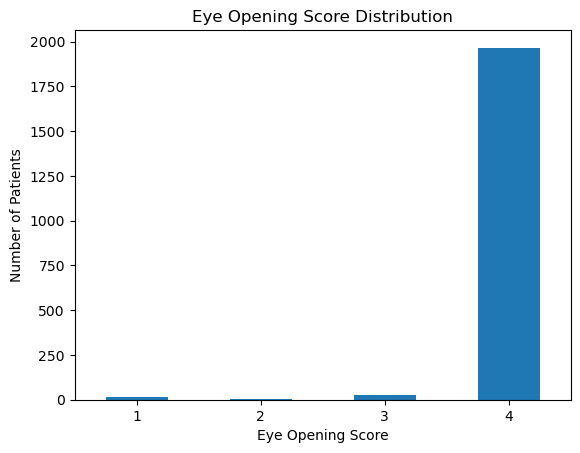

In [81]:
df_responsivenes['eye_opening'].value_counts().sort_index().plot(kind='bar')

plt.title('Eye Opening Score Distribution')
plt.xlabel('Eye Opening Score')
plt.ylabel('Number of Patients')
plt.xticks(rotation=0)
plt.show()

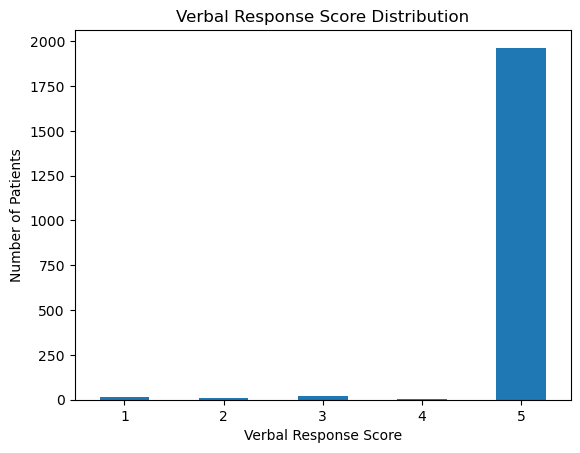

In [82]:
df_responsivenes['verbal_response'].value_counts().sort_index().plot(kind='bar')

plt.title('Verbal Response Score Distribution')
plt.xlabel('Verbal Response Score')
plt.ylabel('Number of Patients')
plt.xticks(rotation=0)
plt.show()

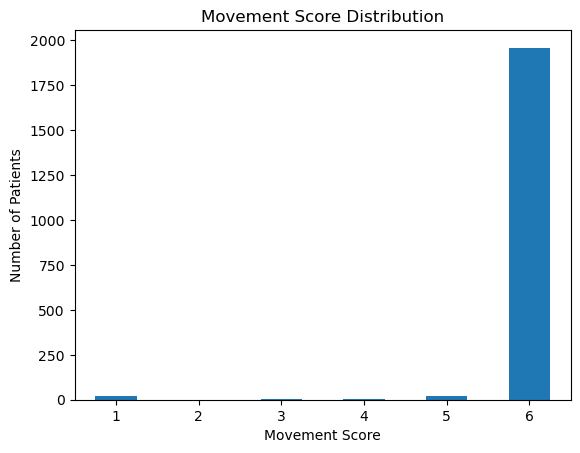

In [83]:
df_responsivenes['movement'].value_counts().sort_index().plot(kind='bar')

plt.title('Movement Score Distribution')
plt.xlabel('Movement Score')
plt.ylabel('Number of Patients')
plt.xticks(rotation=0)
plt.show()

In [84]:
df_responsivenes['consciousness'].value_counts()

consciousness
Clear                1974
ResponsiveToSound      19
Nonresponsive          11
ResponsiveToPain        4
Name: count, dtype: int64

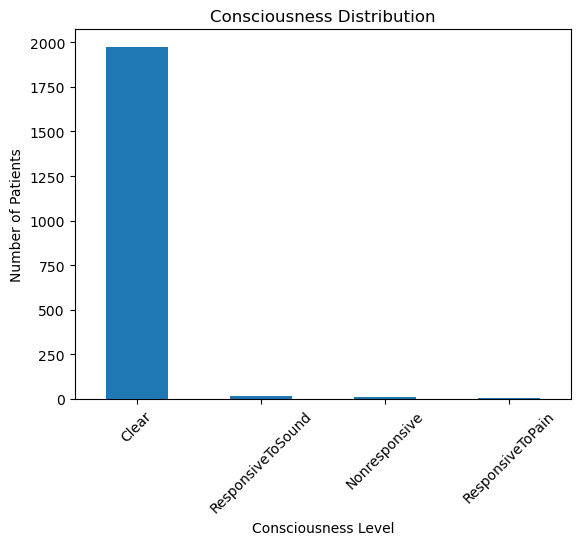

In [85]:
df_responsivenes['consciousness'].value_counts().plot(kind='bar')

plt.title('Consciousness Distribution')
plt.xlabel('Consciousness Level')
plt.ylabel('Number of Patients')
plt.xticks(rotation=45)
plt.show()

In [86]:
df_responsivenes['gcs'].value_counts().sort_index()

gcs
3       13
4        1
6        1
7        4
10       7
11      19
12       3
13       2
14       7
15    1951
Name: count, dtype: int64

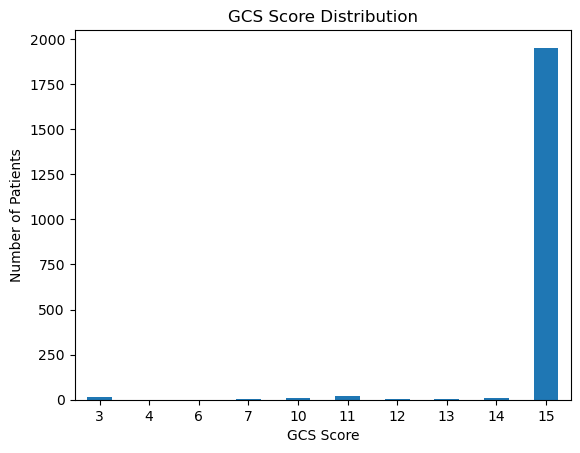

In [87]:
df_responsivenes['gcs'].value_counts().sort_index().plot(kind='bar')

plt.title('GCS Score Distribution')
plt.xlabel('GCS Score')
plt.ylabel('Number of Patients')
plt.xticks(rotation=0)
plt.show()


In [88]:
df_responsivenes['gcs'].min(), df_responsivenes['gcs'].max()

(3, 15)

In [89]:
#gcs = eye_opening + verbal_response + movement.

In [90]:
df_responsivenes['calculated_gcs'] = (
    df_responsivenes['eye_opening'] +
    df_responsivenes['verbal_response'] +
    df_responsivenes['movement']
)

df_responsivenes[df_responsivenes['calculated_gcs'] != df_responsivenes['gcs']]

,inpatient_number,eye_opening,verbal_response,movement,consciousness,gcs,calculated_gcs


In [91]:
df_responsivenes[df_responsivenes['calculated_gcs'] != df_responsivenes['gcs']]

,inpatient_number,eye_opening,verbal_response,movement,consciousness,gcs,calculated_gcs


In [92]:
df_responsivenes[df_responsivenes['calculated_gcs'] != df_responsivenes['gcs']].shape

(0, 7)

In [93]:
df_responsivenes['movement'].min(), df_responsivenes['movement'].max()

(1, 6)

In [94]:
#final data-cleaning checks instead of repeating anything

In [95]:
df_responsivenes['inpatient_number'].nunique()

2008

In [96]:
len(df_responsivenes)

2008

In [97]:
df_responsivenes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2008 entries, 0 to 2007
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   inpatient_number  2008 non-null   object
 1   eye_opening       2008 non-null   int64 
 2   verbal_response   2008 non-null   int64 
 3   movement          2008 non-null   int64 
 4   consciousness     2008 non-null   object
 5   gcs               2008 non-null   int64 
 6   calculated_gcs    2008 non-null   int64 
dtypes: int64(5), object(2)
memory usage: 109.9+ KB


In [98]:
df_responsivenes.drop(columns=['calculated_gcs'], inplace=True)

In [99]:
df_responsivenes.columns.tolist()

['inpatient_number',
 'eye_opening',
 'verbal_response',
 'movement',
 'consciousness',
 'gcs']

In [100]:
df_responsivenes.to_csv("df_responsivenes_cleaned.csv", index=False)
df5_cleaned = pd.read_csv("cardiac_failure/df_responsivenes_cleaned.csv")
df5_cleaned.head

<bound method NDFrame.head of       inpatient_number  eye_opening  verbal_response  movement  consciousness  \
0               857781            4                5         6          Clear   
1               743087            4                5         6          Clear   
2               866418            4                5         6          Clear   
3               775928            4                5         6          Clear   
4               810128            4                5         6          Clear   
...                ...          ...              ...       ...            ...   
2003            740689            4                5         6          Clear   
2004            734280            4                5         6          Clear   
2005            781004            4                5         6          Clear   
2006            744870            1                1         1  Nonresponsive   
2007            791864            4                5         6          Clear  

In [101]:
#patienthistory.csv sudha

In [102]:
df_patienthistory = pd.read_csv("cardiac_failure/patienthistory.csv")

In [103]:
df_patienthistory["inpatient_number"] = df_patienthistory["inpatient_number"].astype(str)

In [104]:
df_patienthistory.head()

,inpatient_number,cerebrovascular_disease,dementia,chronic_obstructive_pulmonary_disease,connective_tissue_disease,peptic_ulcer_disease,diabetes,moderate_to_severe_chronic_kidney_disease,hemiplegia,leukemia,malignant_lymphoma,solid_tumor,liver_disease,aids,cci_score,type_ii_respiratory_failure,acute_renal_failure
0,857781,0,0,1,0,0.0,1,0.0,0,0,0,0,0.0,0,2.0,nontypeii,0
1,743087,0,0,0,0,0.0,0,0.0,0,0,0,0,0.0,0,0.0,nontypeii,0
2,866418,0,0,0,0,0.0,0,0.0,0,0,0,0,0.0,0,0.0,nontypeii,0
3,775928,0,0,1,0,0.0,0,1.0,0,0,0,0,0.0,0,2.0,nontypeii,0
4,810128,0,0,0,0,0.0,0,0.0,0,0,0,0,0.0,0,0.0,nontypeii,0


In [105]:
df_patienthistory.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2008 entries, 0 to 2007
Data columns (total 17 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   inpatient_number                           2008 non-null   object 
 1   cerebrovascular_disease                    2008 non-null   int64  
 2   dementia                                   2008 non-null   int64  
 3   chronic_obstructive_pulmonary_disease      2008 non-null   int64  
 4   connective_tissue_disease                  2008 non-null   int64  
 5   peptic_ulcer_disease                       2006 non-null   float64
 6   diabetes                                   2008 non-null   int64  
 7   moderate_to_severe_chronic_kidney_disease  2006 non-null   float64
 8   hemiplegia                                 2008 non-null   int64  
 9   leukemia                                   2008 non-null   int64  
 10  malignant_lymphoma      

In [106]:
df_patienthistory[df_patienthistory.isnull().any(axis=1)]

,inpatient_number,cerebrovascular_disease,dementia,chronic_obstructive_pulmonary_disease,connective_tissue_disease,peptic_ulcer_disease,diabetes,moderate_to_severe_chronic_kidney_disease,hemiplegia,leukemia,malignant_lymphoma,solid_tumor,liver_disease,aids,cci_score,type_ii_respiratory_failure,acute_renal_failure
467,782088,0,0,0,0,0.0,1,NaN,0,0,0,0,0.0,0,NaN,nontypeii,0
743,791916,0,0,0,0,0.0,1,NaN,0,0,0,0,0.0,0,NaN,nontypeii,1
817,794590,0,0,0,0,NaN,1,1.0,0,0,0,0,0.0,0,NaN,nontypeii,0
1003,818307,0,0,0,0,NaN,1,0.0,0,0,0,0,0.0,0,NaN,nontypeii,0
1497,793609,0,0,0,0,0.0,1,1.0,0,0,0,0,NaN,0,NaN,nontypeii,0


In [107]:
df_patienthistory["cci_score"].value_counts(dropna=False).sort_index()

cci_score
0.0     56
1.0    770
2.0    699
3.0    368
4.0     94
5.0     15
6.0      1
NaN      5
Name: count, dtype: int64

In [108]:
df_patienthistory[df_patienthistory["cci_score"].isnull()]

,inpatient_number,cerebrovascular_disease,dementia,chronic_obstructive_pulmonary_disease,connective_tissue_disease,peptic_ulcer_disease,diabetes,moderate_to_severe_chronic_kidney_disease,hemiplegia,leukemia,malignant_lymphoma,solid_tumor,liver_disease,aids,cci_score,type_ii_respiratory_failure,acute_renal_failure
467,782088,0,0,0,0,0.0,1,NaN,0,0,0,0,0.0,0,NaN,nontypeii,0
743,791916,0,0,0,0,0.0,1,NaN,0,0,0,0,0.0,0,NaN,nontypeii,1
817,794590,0,0,0,0,NaN,1,1.0,0,0,0,0,0.0,0,NaN,nontypeii,0
1003,818307,0,0,0,0,NaN,1,0.0,0,0,0,0,0.0,0,NaN,nontypeii,0
1497,793609,0,0,0,0,0.0,1,1.0,0,0,0,0,NaN,0,NaN,nontypeii,0


In [109]:

#5 rows where cci_score is missing. We should not guess those scores.

#There is also a fifth row (index 1497) where liver_disease is missing, so we need to inspect it separately.

In [110]:
df_patienthistory.groupby(
    ["diabetes", "cerebrovascular_disease", "dementia",
     "chronic_obstructive_pulmonary_disease",
     "connective_tissue_disease",
     "hemiplegia",
     "leukemia",
     "malignant_lymphoma",
     "solid_tumor",
     "aids"]
)["cci_score"].agg(["count", "mean", "median"]).head(20)

count  \
diabetes cerebrovascular_disease dementia chronic_obstructive_pulmonary_disease connective_tissue_disease hemiplegia leukemia malignant_lymphoma solid_tumor aids          
0        0                       0        0                                     0                         0          0        0                  0           0      1134   
                                                                                                                                                             1         3   
                                                                                                                                                 1           0        24   
                                                                                                          1          0        0                  0           0         1   
                                                                                1                         0          0        0                  0           0         2   
                                          1                                     0                         0          0        0                  0           0       169   
                                                                                                                                                 1           0         4   
                                                                                1                         0          0        0                  0           0         1   
                                                                                                                                                 1           0         1   
                                 1        0                                     0                         0          0        0                  0           0        90   
         1                       0        0                                     0                         0          0        0                  0           0        83   
                                                                                                                                                 1           0         1   
                                                                                                          1          0        0                  0           0         7   
                                          1                                     0                         0          0        0                  0           0        15   
                                                                                                                                                 1           0         1   
                                 1        0                                     0                         0          0        0                  0           0         6   
1        0                       0        0                                     0                         0          0        0                  0           0       356   
                                                                                                                                                             1         1   
                                                                                                                                                 1           0         7   
                                          1                                     0                         0          0        0                  0           0        40   

                                                                                                                                                                       mean  \
diabetes cerebrovascular_disease dementia chronic_obstructive_pulmonary_disease connective_tissue_disease hemiplegia leukemia malignant_lymphoma solid_tumor aids             
0        0                  

In [111]:
missing_cci = df_patienthistory[df_patienthistory["cci_score"].isna()]

missing_cci

,inpatient_number,cerebrovascular_disease,dementia,chronic_obstructive_pulmonary_disease,connective_tissue_disease,peptic_ulcer_disease,diabetes,moderate_to_severe_chronic_kidney_disease,hemiplegia,leukemia,malignant_lymphoma,solid_tumor,liver_disease,aids,cci_score,type_ii_respiratory_failure,acute_renal_failure
467,782088,0,0,0,0,0.0,1,NaN,0,0,0,0,0.0,0,NaN,nontypeii,0
743,791916,0,0,0,0,0.0,1,NaN,0,0,0,0,0.0,0,NaN,nontypeii,1
817,794590,0,0,0,0,NaN,1,1.0,0,0,0,0,0.0,0,NaN,nontypeii,0
1003,818307,0,0,0,0,NaN,1,0.0,0,0,0,0,0.0,0,NaN,nontypeii,0
1497,793609,0,0,0,0,0.0,1,1.0,0,0,0,0,NaN,0,NaN,nontypeii,0


In [112]:
df_patienthistory.loc[1497]

inpatient_number                                793609
cerebrovascular_disease                              0
dementia                                             0
chronic_obstructive_pulmonary_disease                0
connective_tissue_disease                            0
peptic_ulcer_disease                               0.0
diabetes                                             1
moderate_to_severe_chronic_kidney_disease          1.0
hemiplegia                                           0
leukemia                                             0
malignant_lymphoma                                   0
solid_tumor                                          0
liver_disease                                      NaN
aids                                                 0
cci_score                                          NaN
type_ii_respiratory_failure                  nontypeii
acute_renal_failure                                  0
Name: 1497, dtype: object

In [113]:
df_patienthistory.isnull().sum()


inpatient_number                             0
cerebrovascular_disease                      0
dementia                                     0
chronic_obstructive_pulmonary_disease        0
connective_tissue_disease                    0
peptic_ulcer_disease                         2
diabetes                                     0
moderate_to_severe_chronic_kidney_disease    2
hemiplegia                                   0
leukemia                                     0
malignant_lymphoma                           0
solid_tumor                                  0
liver_disease                                1
aids                                         0
cci_score                                    5
type_ii_respiratory_failure                  0
acute_renal_failure                          0
dtype: int64

In [114]:
#The patienthistory.csv dataset contains 10 missing values across four columns: peptic_ulcer_disease (2), moderate_to_severe_chronic_kidney_disease (2), liver_disease (1), and cci_score (5). Missing values were retained as NaN because the available
#data does not provide sufficient information to reliably determine the missing clinical values.

In [115]:
df_patienthistory.duplicated().sum()

0

In [116]:
df_patienthistory["inpatient_number"].duplicated().sum()

0

In [117]:
binary_columns = [
    "cerebrovascular_disease",
    "dementia",
    "chronic_obstructive_pulmonary_disease",
    "connective_tissue_disease",
    "peptic_ulcer_disease",
    "diabetes",
    "moderate_to_severe_chronic_kidney_disease",
    "hemiplegia",
    "leukemia",
    "malignant_lymphoma",
    "solid_tumor",
    "liver_disease",
    "aids",
    "acute_renal_failure"
]

for col in binary_columns:
    print(col, df_patienthistory[col].dropna().unique())

cerebrovascular_disease [0 1]
dementia [0 1]
chronic_obstructive_pulmonary_disease [1 0]
connective_tissue_disease [0 1]
peptic_ulcer_disease [0. 1.]
diabetes [1 0]
moderate_to_severe_chronic_kidney_disease [0. 1.]
hemiplegia [0 1]
leukemia [0]
malignant_lymphoma [0 1]
solid_tumor [0 1]
liver_disease [0. 1.]
aids [0 1]
acute_renal_failure [0 1]


In [118]:
df_patienthistory["type_ii_respiratory_failure"].value_counts(dropna=False)

type_ii_respiratory_failure
nontypeii    1894
typeii        114
Name: count, dtype: int64

In [119]:
df_patienthistory["cci_score"].dropna().unique()

array([2., 0., 1., 3., 4., 5., 6.])

In [120]:
df_patienthistory["cci_score"] = df_patienthistory["cci_score"].astype("Int64")



In [121]:
df_patienthistory["cci_score"].value_counts(dropna=False)

cci_score
1       770
2       699
3       368
4        94
0        56
5        15
<NA>      5
6         1
Name: count, dtype: Int64

In [122]:
binary_missing_cols = [
    "peptic_ulcer_disease",
    "moderate_to_severe_chronic_kidney_disease",
    "liver_disease"
]

for col in binary_missing_cols:
    df_patienthistory[col] = df_patienthistory[col].astype("Int64")

In [123]:
df_patienthistory[binary_missing_cols].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2008 entries, 0 to 2007
Data columns (total 3 columns):
 #   Column                                     Non-Null Count  Dtype
---  ------                                     --------------  -----
 0   peptic_ulcer_disease                       2006 non-null   Int64
 1   moderate_to_severe_chronic_kidney_disease  2006 non-null   Int64
 2   liver_disease                              2007 non-null   Int64
dtypes: Int64(3)
memory usage: 53.1 KB


In [124]:
print("Shape:", df_patienthistory.shape)

print("\nMissing values:")
print(df_patienthistory.isnull().sum())

print("\nDuplicate rows:", df_patienthistory.duplicated().sum())

print("Duplicate inpatient numbers:",
      df_patienthistory["inpatient_number"].duplicated().sum())

Shape: (2008, 17)

Missing values:
inpatient_number                             0
cerebrovascular_disease                      0
dementia                                     0
chronic_obstructive_pulmonary_disease        0
connective_tissue_disease                    0
peptic_ulcer_disease                         2
diabetes                                     0
moderate_to_severe_chronic_kidney_disease    2
hemiplegia                                   0
leukemia                                     0
malignant_lymphoma                           0
solid_tumor                                  0
liver_disease                                1
aids                                         0
cci_score                                    5
type_ii_respiratory_failure                  0
acute_renal_failure                          0
dtype: int64

Duplicate rows: 0
Duplicate inpatient numbers: 0


In [125]:
df_patienthistory.to_csv("df_patienthistory_cleaned.csv", index=False)
df6_cleaned = pd.read_csv("cardiac_failure/df_patienthistory_cleaned.csv")
df6_cleaned.head

<bound method NDFrame.head of       inpatient_number  cerebrovascular_disease  dementia  \
0               857781                        0         0   
1               743087                        0         0   
2               866418                        0         0   
3               775928                        0         0   
4               810128                        0         0   
...                ...                      ...       ...   
2003            740689                        0         0   
2004            734280                        0         0   
2005            781004                        0         0   
2006            744870                        0         0   
2007            791864                        0         0   

      chronic_obstructive_pulmonary_disease  connective_tissue_disease  \
0                                         1                          0   
1                                         0                          0   
2              

In [126]:
### Patient History Data Cleaning Summary
#The patient history dataset contains 2,008 records and 17 columns.
#Data cleaning included:
#- Checked the dataset structure and data types.
#- Checked and documented missing values.
#- Validated binary disease indicators to ensure values were 0 or 1.
#- Validated CCI scores, which ranged from 0 to 6.
#- Converted relevant columns to nullable integer (`Int64`) types while preserving missing values.
#- Verified that there are no duplicate rows.
#- Verified that there are no duplicate inpatient numbers.
#- Validated `type_ii_respiratory_failure` categories.
#A total of 10 missing values remain in four clinical columns. These values were retained as missing (`<NA>`) because there was insufficient information to reliably determine the missing clinical values.

In [127]:
#sudha work end Patient history

In [128]:
# Priya Demographics works starts here 

In [129]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Hackathon Data Cleaning Pipeline: Demographic Dataset

## Executive Overview
This notebook performs data cleaning, outlier handling, type casting, and feature engineering 
on the demographic patient dataset. 

### Data Quality Issues Addressed:
- Removal of corrupted baseline test records.
- Proper data type conversion for ID strings and categorical variables.
- Detection and correction of biologically impossible heights (< 1.0) 
- and weights (< 10.0 kg).
- Recalculation of Body Mass Index (BMI).
- Standardizing messy text entries and feature engineering clinical risk categories.


In [130]:
import numpy as np
import pandas as pd

In [131]:
# 1. Load raw dataset
df_demography = pd.read_csv("cardiac_failure/demography.csv")

In [132]:
# 2. Create working copy to preserve raw baseline
df_clean = df_demography.copy()

In [133]:
# 3. Baseline Audit
print(f"Dataset Dimensions: {df_clean.shape[0]} rows, {df_clean.shape[1]} columns")
print("\n--- Initial Data Types ---")
print(df_clean.dtypes)
print("\n--- Initial Null Counts ---")
print(df_clean.isnull().sum())

Dataset Dimensions: 2009 rows, 7 columns

--- Initial Data Types ---
inpatient_number      int64
gender               object
weight              float64
height              float64
bmi                 float64
occupation           object
agecat               object
dtype: object

--- Initial Null Counts ---
inpatient_number     0
gender               1
weight               1
height               1
bmi                  0
occupation          28
agecat               1
dtype: int64


## Step 1: Record Filtering & Identifier Type Casting

### Actions:
1. **Remove Corrupted Test Row**: Row index 0 (`inpatient_number = 5`) is a dummy test 
   record containing `NaN` across all attributes with an isolated BMI value.
2. **Convert ID Data Type**: Convert `inpatient_number` from numerical `int64` to `str` 
   to avoid misidentifying patient IDs as quantitative numbers in statistical summaries.

In [134]:
# 1. Deduplicate columns first in case they were doubled previously
df_clean = df_clean.loc[:, ~df_clean.columns.duplicated()]

# 2. Convert inpatient_number to string on df_clean
df_clean["inpatient_number"] = (
    df_clean["inpatient_number"].astype(str).str.strip()
)

# 3. Drop row where inpatient_number is '5' or '5.0' and reset index
df_clean = df_clean[
    ~df_clean["inpatient_number"].isin(["5", "5.0"])
].reset_index(drop=True)

# 4. Verify shape (Outputs 2008, 7)
print(f"Updated Shape: {df_clean.shape}")
print(f"inpatient_number Data Type: {df_clean['inpatient_number'].dtype}")

Updated Shape: (2008, 7)
inpatient_number Data Type: object


In [135]:

# Verify change
print(f"Updated Shape: {df_clean.shape}")
print(f"inpatient_number Data Type: {df_clean['inpatient_number'].dtype}")

Updated Shape: (2008, 7)
inpatient_number Data Type: object


## Step 2: Biological Outlier Detection & Calculation Fixes

### Actions:
1. **Flag Impossible Measurements**: 
   - Heights under 1.0 (0.35m - 0.60 m) are adult data entry errors and distort calculated BMIs (> 400).
   - Weights < 10.0 kg including 0.0 kg are invalid.
2. **Set Anomalies to `NaN`**: Replace invalid physical measurements with `NaN`.
3. **Recalculate BMI**: Recompute accurate BMIs using the standard formula:
   $$\text{BMI} = \frac{\text{Weight (kg)}}{\text{Height (m)}^2}$$

In [136]:
# 1. Create missingness flags for auditability
df_clean["flag_invalid_height"] = df_clean["height"] < 1.0
df_clean["flag_invalid_weight"] = df_clean["weight"] <= 10.0

# 2. Replace impossible entries with NaN
df_clean.loc[df_clean["flag_invalid_height"], "height"] = np.nan
df_clean.loc[df_clean["flag_invalid_weight"], "weight"] = np.nan

# 3. Recalculate true BMI
df_clean["bmi"] = df_clean["weight"] / (df_clean["height"] ** 2)

# Display summary statistics after cleanup
print("--- Sanitized BMI Summary Statistics ---")
print(df_clean["bmi"].describe())

--- Sanitized BMI Summary Statistics ---
count    2000.000000
mean       21.296969
std         3.807980
min        13.061224
25%        18.491124
50%        20.761246
75%        23.437500
max        39.111111
Name: bmi, dtype: float64


## Step 3: Categorical Standardization & Feature Engineering

### Actions:
1. **Standardize Text Fields**: Fix inconsistent casing in `occupation` (e.g., `farmer` $\rightar
`Farmer`, `UrbanResident` $\rightarrow$ `Urban Resident`) and handle missing values by filling 
them with `"Unspecified"`.
2. **Ordered Categorical Conversion**: Convert `agecat` into an ordered categorical data type 
(`21-29` < `29-39` < ... < `89-110`) to preserve correct age progression in charts.
3. **Feature Engineering**: Bin continuous BMI values into World Health Organization clinical
risk categories (`Underweight`, `Normal`, `Overweight`, `Obese`).

In [137]:
# 1. Standardize occupation names
occupation_map = {
    "farmer": "Farmer",
    "worker": "Worker",
    "UrbanResident": "Urban Resident",
    "Officer": "Officer",
    "Others": "Others",
}
df_clean["occupation"] = (
    df_clean["occupation"].map(occupation_map).fillna("Unspecified")
)

# 2. Set Gender categorical
df_clean["gender"] = df_clean["gender"].astype("category")

# 3. Set Ordered Categorical Age Ranges
age_order = [
    "21-29",
    "29-39",
    "39-49",
    "49-59",
    "59-69",
    "69-79",
    "79-89",
    "89-110",
]
df_clean["agecat"] = pd.Categorical(
    df_clean["agecat"], categories=age_order, ordered=True
)

# 4. Feature Engineering: Clinical BMI Risk Categories
bmi_bins = [0, 18.5, 24.9, 29.9, np.inf]
bmi_labels = ["Underweight", "Normal", "Overweight", "Obese"]
df_clean["bmi_category"] = pd.cut(
    df_clean["bmi"], bins=bmi_bins, labels=bmi_labels
)

# Check value distributions
print("--- Occupation Distribution ---")
print(df_clean["occupation"].value_counts())
print("\n--- BMI Risk Category Distribution ---")
print(df_clean["bmi_category"].value_counts())

--- Occupation Distribution ---
occupation
Urban Resident    1670
Farmer             198
Others              89
Unspecified         27
Worker              17
Officer              7
Name: count, dtype: int64

--- BMI Risk Category Distribution ---
bmi_category
Normal         1163
Underweight     507
Overweight      263
Obese            67
Name: count, dtype: int64


## Step 4: Final Validation & Export

### Actions:
1. Confirm final column data types and check remaining null counts.
2. Export the clean dataset to `Demography_Cleaned.csv` for downstream merging.

In [138]:
# 1. Final datatypes check
print("--- Final Data Types ---")
print(df_clean.dtypes)

# 2. Final missing value audit
print("\n--- Final Null Counts ---")
print(df_clean.isnull().sum())

# 3. Export cleaned data
df_clean.to_csv("Demography_Cleaned.csv", index=False)
print(
    f"\nDataset cleaned successfully! Output saved with shape {df_clean.shape}."
)

--- Final Data Types ---
inpatient_number         object
gender                 category
weight                  float64
height                  float64
bmi                     float64
occupation               object
agecat                 category
flag_invalid_height        bool
flag_invalid_weight        bool
bmi_category           category
dtype: object

--- Final Null Counts ---
inpatient_number       0
gender                 0
weight                 4
height                 4
bmi                    8
occupation             0
agecat                 0
flag_invalid_height    0
flag_invalid_weight    0
bmi_category           8
dtype: int64

Dataset cleaned successfully! Output saved with shape (2008, 10).


#Check or Open the File Path Using Code
Run this quick code cell in Jupyter Notebook to display the exact folder path where your file was saved:

In [139]:
# 1. Save df_clean (the filtered dataset) instead of df_demography
df_clean.to_csv("cardiac_failure/df_demography_cleaned.csv", index=False)

# 2. Re-read to confirm what was written to disk
df10_cleaned = pd.read_csv("cardiac_failure/df_demography_cleaned.csv")

# 3. Print verified shape (Will now show 2008 rows!)
print(f"Cleaned CSV Shape: {df10_cleaned.shape}")

# 4. Display the top 5 rows using head() with parentheses
df10_cleaned.head()

Cleaned CSV Shape: (2008, 10)


,inpatient_number,gender,weight,height,bmi,occupation,agecat,flag_invalid_height,flag_invalid_weight,bmi_category
0,827040,Female,50.0,1.45,23.781213,Unspecified,69-79,False,False,Normal
1,857781,Male,50.0,1.64,18.590125,Urban Resident,69-79,False,False,Normal
2,743087,Female,51.0,1.63,19.195303,Urban Resident,69-79,False,False,Normal
3,866418,Male,70.0,1.70,24.221453,Farmer,59-69,False,False,Normal
4,775928,Male,65.0,1.70,22.491349,Urban Resident,69-79,False,False,Normal


In [140]:
import pandas as pd
# 1. Load the cleaned demography file
df_demography = pd.read_csv("cardiac_failure/df_demography_cleaned.csv")

# 2. Check total null values per column
print("--- Missing Values Per Column ---")
print(df_demography.isnull().sum())

print("\n--- Summary ---")
# 3. Check overall total nulls across the entire dataset
total_nulls = df_demography.isnull().sum().sum()
print(f"Total Null Values in Dataset: {total_nulls}")

--- Missing Values Per Column ---
inpatient_number       0
gender                 0
weight                 4
height                 4
bmi                    8
occupation             0
agecat                 0
flag_invalid_height    0
flag_invalid_weight    0
bmi_category           8
dtype: int64

--- Summary ---
Total Null Values in Dataset: 24


#Priya Demography table Data cleaning ends here

#Priya Patient Presciption Data Cleaning starts here

# Hackathon Data Cleaning & Reshaping Pipeline: Patient Prescriptions Table

## Executive Overview
This notebook processes the `patient_prescriptions.csv` transactional dataset. 

### Key Processing Actions:
1. **Load & Copy**: Load the raw transactional data and create an isolated working copy.
2. **Identifier & Text Cleaning**: Convert `inpatient_number` to string data type and strip unintended whitespace from drug names.
3. **Reshaping (Long to Wide Format)**:
   - Compute the total medication burden (`total_prescriptions_count`) per patient.
   - One-hot encode the **25 exact unique drug names** directly from the raw dataset rows into binary columns (`1` = Prescribed, `0` = Not Prescribed) so each patient has exactly one row.
4. **Validation & Export**: Verify structural integrity and export the final patient-level table.

In [141]:
import numpy as np
import pandas as pd

# 1. Load raw dataset (adjust folder path if your file is inside a subfolder like 'cardiac_failure/')
df_prescriptions_raw = pd.read_csv("cardiac_failure/patient_precriptions.csv")

# 2. Create a working copy to preserve raw data in memory
df_rx = df_prescriptions_raw.copy()

# 3. Baseline Audit
print(f"Raw Dataset Dimensions: {df_rx.shape[0]} rows, {df_rx.shape[1]} columns")
print(f"Unique Patients Count: {df_rx['inpatient_number'].nunique()}")
print(f"Unique Drug Names Count: {df_rx['drug_name'].nunique()}")
print("\n--- Initial Null Values Audit ---")
print(df_rx.isnull().sum())

Raw Dataset Dimensions: 15362 rows, 2 columns
Unique Patients Count: 2007
Unique Drug Names Count: 25

--- Initial Null Values Audit ---
inpatient_number    0
drug_name           0
dtype: int64


## Step 1: Identifier Type Casting & Text Standardization

### Actions:
1. Convert `inpatient_number` from `int64` to `str` to ensure consistent keys when merging with Demography and Clinical tables.
2. Strip unexpected leading/trailing whitespaces from `drug_name` strings to prevent text formatting mismatches.

In [142]:
# 1. Convert patient ID to string data type
df_rx["inpatient_number"] = df_rx["inpatient_number"].astype(str)

# 2. Clean whitespace in drug names
df_rx["drug_name"] = df_rx["drug_name"].str.strip()

# Verify data type change
print(f"inpatient_number Data Type: {df_rx['inpatient_number'].dtype}")

inpatient_number Data Type: object


## Step 2: Aggregation & Reshaping (Long Format to Wide Format)

### Actions:
Machine learning models require **one row per patient**. We transform the transactional rows using:
1. **Total Prescription Count**: Group by `inpatient_number` to calculate total prescriptions per patient (`total_prescriptions_count`).
2. **One-Hot Encoding (Pivot)**: Pivot the 25 exact drug names present in the raw data into binary indicator columns (`1` or `0`).
3. **Merge Features**: Combine count and individual drug flags into a unified 1-row-per-patient dataset (**27 columns total**).

## Step 3: Reshaping from Long Format to Patient-Level Wide Format

### Actions:
1. **Total Medication Count**: Calculate total number of drugs prescribed to each patient (`total_prescriptions_count`).
2. **One-Hot Encoding**: Pivot individual drug names into binary indicator columns (`1` = Prescribed, `0` = Not Prescribed).
3. **Class Indicator Encoding**: Pivot therapeutic drug classes into binary flags (`1` = On Class Therapy, `0` = Not On Class Therapy).

In [143]:
# 1. Calculate total prescription count per patient
df_patient_count = (
    df_rx.groupby("inpatient_number")["drug_name"]
    .count()
    .reset_index(name="total_prescriptions_count")
)

# 2. One-Hot Encode the exact 25 drug names directly from dataset rows
df_drugs_pivot = (
    pd.crosstab(df_rx["inpatient_number"], df_rx["drug_name"])
    .clip(upper=1)
    .reset_index()
)

# Clean drug column names for pythonic access (spaces/hyphens converted to underscores with 'rx_' prefix)
df_drugs_pivot.columns = [
    col if col == "inpatient_number" else f"rx_{col.lower().replace(' ', '_')}"
    for col in df_drugs_pivot.columns
]

# 3. Merge into a single Patient-Level Wide Table
df_prescriptions_patient_level = df_patient_count.merge(
    df_drugs_pivot, on="inpatient_number"
)

# Display transformed structure
print("Transformed Patient-Level Prescriptions Table Preview:")
print(f"Shape: {df_prescriptions_patient_level.shape} (Expected: 2007 rows, 27 columns)")
df_prescriptions_patient_level.head()

Transformed Patient-Level Prescriptions Table Preview:
Shape: (2007, 27) (Expected: 2007 rows, 27 columns)


,inpatient_number,total_prescriptions_count,rx_aspirin_enteric-coated_tablet,rx_atorvastatin_calcium_tablet,rx_benazepril_hydrochloride_tablet,rx_clopidogrel_hydrogen_sulphate_tablet,rx_deslanoside_injection,rx_digoxin_tablet,rx_dobutamine_hydrochloride_injection,rx_enoxaparin_sodium_injection,...,rx_metoprolol_succinate_sustained-release_tablet,rx_milrinone_injection,rx_nitroglycerin_injection,rx_shenfu_injection,rx_spironolactone_tablet,rx_torasemide_tablet,rx_valsartan_dispersible_tablet,rx_metoprolol_tartrate_injection,rx_sulfotanshinone_sodium_injection,rx_warfarin_sodium_tablet
0,722128,7,0,0,0,0,1,1,0,0,...,0,1,0,0,1,0,0,0,0,1
1,723327,12,1,1,0,1,1,1,0,0,...,0,1,0,0,1,1,1,0,0,0
2,723617,4,0,1,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
3,724385,6,0,0,0,0,1,1,0,0,...,0,1,0,0,1,0,0,0,0,0
4,725509,9,0,0,0,0,1,1,0,0,...,0,1,0,1,1,1,0,1,0,0


## Step 3: Final Validation, Path Inspection & Export

### Actions:
1. Validate that the patient count equals 2,007 unique patients and check for missing values.
2. Export the clean dataset to `Patient_Prescriptions_Cleaned.csv` in your working directory.
3. Print the exact file save path to confirm location.

In [144]:
df_prescriptions_patient_level.to_csv(
    "df_Patient_Prescriptions_Cleaned.csv", index=False
)
df11_cleaned = pd.read_csv("cardiac_failure/df_Patient_Prescriptions_Cleaned.csv")
df11_cleaned.head

<bound method NDFrame.head of       inpatient_number  total_prescriptions_count  \
0               722128                          7   
1               723327                         12   
2               723617                          4   
3               724385                          6   
4               725509                          9   
...                ...                        ...   
2002            870258                          8   
2003            870646                          6   
2004            879601                         13   
2005            905163                         11   
2006            905720                          9   

      rx_aspirin_enteric-coated_tablet  rx_atorvastatin_calcium_tablet  \
0                                    0                               0   
1                                    1                               1   
2                                    0                               1   
3                                    

In [145]:
import os

# 1. Validation Checks
assert (
    df_prescriptions_patient_level["inpatient_number"].nunique() == 2007
), "Patient count mismatch!"
assert (
    df_prescriptions_patient_level.isnull().sum().sum() == 0
), "Null values found in transformed table!"

# 2. Export clean CSV
output_filename = "Patient_Prescriptions_Cleaned.csv"
df_prescriptions_patient_level.to_csv(output_filename, index=False)


# 3. Verification & Absolute File Path Display
print("--- Export Summary ---")
print(f"File Saved Successfully: {os.path.exists(output_filename)}")
print(f"Absolute File Path: {os.path.abspath(output_filename)}")
print(f"Final Output Shape: {df_prescriptions_patient_level.shape}")
print(f"Total Columns Count: {df_prescriptions_patient_level.shape[1]}")

--- Export Summary ---
File Saved Successfully: True
Absolute File Path: C:\Users\Priyankha Kumar\Desktop\Priyankha Kumar Career Numpy Ninja\Python Hackathon\Team4_The_Zen_OF_Five_PythonHackathon_Sep2026_Friday\Patient_Prescriptions_Cleaned.csv
Final Output Shape: (2007, 27)
Total Columns Count: 27


In [146]:
#Priya Patient Prescription code ends here

# Final merging of all the 7 csv files 

#Making the table aggregation for all 7 csv files

In [147]:
merge_files = {
    'demography': 'cardiac_failure/df_demography_cleaned.csv',
    'prescriptions': 'cardiac_failure/df_Patient_Prescriptions_Cleaned.csv',
    'history': 'cardiac_failure/df_patienthistory_cleaned.csv',
    'responsiveness': 'cardiac_failure/df_responsivenes_cleaned.csv',
    'discharge': 'cardiac_failure/hospitalization_discharge_cleaned.csv',
    'labs': 'cardiac_failure/labs_cleaned.csv',
    'cardiac': 'cardiac_failure/cardiac_complications_cleaned.csv',
}

In [148]:
dfs = {}
for name, path in merge_files.items():
    dfs[name] = pd.read_csv(path)
    print(f"{name:15s} shape={dfs[name].shape}  "
          f"unique inpatient_number={dfs[name]['inpatient_number'].nunique()}")

demography      shape=(2008, 10)  unique inpatient_number=2008
prescriptions   shape=(2007, 27)  unique inpatient_number=2007
history         shape=(2008, 17)  unique inpatient_number=2008
responsiveness  shape=(2008, 6)  unique inpatient_number=2008
discharge       shape=(2008, 21)  unique inpatient_number=2008
labs            shape=(2008, 111)  unique inpatient_number=2008
cardiac         shape=(2008, 14)  unique inpatient_number=2008


In [149]:
for name, df in dfs.items():
    dup_count = df['inpatient_number'].duplicated().sum()
    if dup_count > 0:
        print(f"WARNING: {name} has {dup_count} duplicate inpatient_number values")

# Compare patient coverage across files
all_ids = set(dfs['demography']['inpatient_number'])
for name, df in dfs.items():
    missing = all_ids - set(df['inpatient_number'])
    if missing:
        print(f"{name}: missing {len(missing)} patients present in demography -> {sorted(missing)[:5]}...")

prescriptions: missing 1 patients present in demography -> [789308]...


In [150]:
from functools import reduce

# Order doesn't matter much here since it's a left-to-right outer/left join chain,
# but starting with demography as the "base" patient list makes sense
merge_order = ['demography', 'prescriptions', 'history', 'responsiveness', 'discharge', 'labs', 'cardiac']

master_df = reduce(
    lambda left, right_name: pd.merge(
        left, dfs[right_name],
        on='inpatient_number',
        how='left'          # keep all patients from demography, fill missing with NaN
    ),
    merge_order[1:],
    dfs[merge_order[0]]
)

print("Master table shape:", master_df.shape)
master_df.head()

Master table shape: (2008, 200)


,inpatient_number,gender,weight,height,bmi,occupation,agecat,flag_invalid_height,flag_invalid_weight,bmi_category,...,congestive_heart_failure,peripheral_vascular_disease,type_of_heart_failure,lvef,left_ventricular_end_diastolic_diameter_lv,mitral_valve_ems,mitral_valve_ams,ea,tricuspid_valve_return_velocity,tricuspid_valve_return_pressure
0,827040,Female,50.0,1.45,23.781213,Unspecified,69-79,False,False,Normal,...,1,0,Both,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,857781,Male,50.0,1.64,18.590125,Urban Resident,69-79,False,False,Normal,...,0,0,Both,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,743087,Female,51.0,1.63,19.195303,Urban Resident,69-79,False,False,Normal,...,0,0,Both,NaN,40.0,1.16,1.52,NaN,3.34,47.0
3,866418,Male,70.0,1.70,24.221453,Farmer,59-69,False,False,Normal,...,0,0,Both,NaN,46.0,0.84,0.12,7.0,2.80,32.0
4,775928,Male,65.0,1.70,22.491349,Urban Resident,69-79,False,False,Normal,...,0,0,Both,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [151]:
# Should equal number of unique patients in demography
assert master_df['inpatient_number'].nunique() == dfs['demography']['inpatient_number'].nunique()
assert master_df.shape[0] == dfs['demography'].shape[0]

# Total columns should be sum of all columns minus 6 duplicate 'inpatient_number' columns (one kept per merge)
expected_cols = sum(df.shape[1] for df in dfs.values()) - (len(dfs) - 1)
print(f"Expected columns: {expected_cols}, Actual columns: {master_df.shape[1]}")

# Check how much missing data each source contributes
for name, df in dfs.items():
    if name == 'demography':
        continue
    cols_from_source = [c for c in df.columns if c != 'inpatient_number']
    missing_pct = master_df[cols_from_source].isna().all(axis=1).mean() * 100
    print(f"{name}: {missing_pct:.1f}% of patients have no data from this source")

Expected columns: 200, Actual columns: 200
prescriptions: 0.0% of patients have no data from this source
history: 0.0% of patients have no data from this source
responsiveness: 0.0% of patients have no data from this source
discharge: 0.0% of patients have no data from this source
labs: 0.0% of patients have no data from this source
cardiac: 0.0% of patients have no data from this source


In [152]:
master_df.to_csv('cardiac_failure/cf_master_dataset.csv', index=False)
print("Saved cf_master_dataset.csv with shape:", master_df.shape)

Saved cf_master_dataset.csv with shape: (2008, 200)
